# Inferindo a distribuição do período de rotação das estrelas a partir do $v \sin i$ e raio estelar (Masuda, Petigura and Hall, 2022)

Iremos destrinchar o paper de [Masuda (2022)](https://academic.oup.com/mnras/article/510/4/5623/6464198) completamente nesse notebook para entendermos se é possível usar na nossa amostra.

## Introdução

O estudo da rotação estelar foi revolucionado pela fotometria de alta precisão, contínua e de longo prazo disponibilizada pela missão Kepler. Variações quase periódicas no brilho devido a regiões ativas na superfície permitiram medições do período de rotação para dezenas de milhares de estrelas FGKM, incluindo aquelas com períodos mais longos e/ou variabilidades de menor amplitude do que as que podem ser estudadas com fotometria baseada em solo. Os dados das missões espaciais em andamento, como TESS e Gaia, expandirão ainda mais a capacidade das medições baseadas em fotometria.

Dito isso, o método fotométrico não é isento de limitações. Para estrelas semelhantes ao Sol, a fração de estrelas com modulação rotacional detectada de forma robusta é inferior a cerca de um terço, mesmo nos dados da Kepler; não há informações disponíveis para a maioria da amostra. A função de seleção para a detecção de períodos é difícil de quantificar, e a detectabilidade da modulação rotacional também provavelmente está correlacionada com várias propriedades, incluindo idade estelar, período de rotação, inclinação do giro e distribuição superficial das regiões ativas. Esses são frequentemente os exatos aspectos que se deseja estudar, e essa função de seleção desconhecida complica a interpretação dos estudos de conjuntos. Mesmo quando uma periodicidade é firmemente detectada, não é uma tarefa trivial distinguir a modulação rotacional de outras variabilidades astrofísicas, e a relação entre a periodicidade detectada e a verdadeira (por exemplo, o período detectado pode corresponder a harmônicos do período verdadeiro) depende do método utilizado para analisar os componentes de frequência da curva de luz, bem como da morfologia desconhecida das regiões ativas da superfície. De fato, medições fotométricas individuais nem sempre estão em bom acordo com medições presumivelmente mais confiáveis usando a divisão rotacional dos modos de oscilação asterossísmica.

Essas dificuldades motiva o estudo de um método alternativo usando a velocidade rotacional projetada $ v \sin i $ medida a partir do alargamento da linha de absorção. Ignorando a rotação diferencial,
$$ v \sin i = \dfrac{2 \pi R}{P_{\text{rot}}} \sin i $$
pode ser 'resolvido' para o período de rotação $ P_{\text{rot}} $ - se o raio $ R $ for conhecido a partir de outras medições e as orientações do giro forem isotrópicas (ou seja, $ \cos i $ tem uma distribuição uniforme, onde $ i $ é a inclinação do eixo de giro medida a partir da nossa linha de visão). Uma vantagem chave do método $ v \sin i $ é que ele não é tendencioso contra estrelas menos ativas que podem não apresentar variações detectáveis no brilho fotométrico. Embora o método exija espectros de alta resolução e medições precisas dos raios estelares, levantamentos espectroscópicos que fornecem espectros de alta resolução para milhões de estrelas, combinados com informações de paralaxe do Gaia, superarão essas limitações do método e expandirão significativamente sua aplicabilidade.

Um desafio para essa inferência é que o $ P_{\text{rot}} $ das estrelas individuais não pode ser medido com precisão devido ao $ \sin i $ desconhecido, e que é necessário trabalhar com uma distribuição de $ P_{\text{rot}} $ para uma amostra de muitas estrelas. Essa 'retificação' do fator $ \sin i $ é em si um problema resolvido: assumindo orientações isotrópicas do giro, a relação entre as distribuições de $$ q \equiv \dfrac{v \sin i}{ 2 \pi R} $$ e a de $$ \dfrac{q}{\sin i} = \dfrac{1}{P_{\text{rot}}} $$ pode ser reduzida à equação integral de Abel, que pode ser resolvida analiticamente. Isso envolve a diferenciação da função densidade de probabilidade (PDF) para $ q $, e assim [Chandrasekhar \& Münch (1950)](https://articles.adsabs.harvard.edu/pdf/1950ApJ...111..142C) observaram que deve-se focar nos momentos, ou assumir formas funcionais simples para a PDF $ f(q) $. Uma abordagem alternativa é adotar um algoritmo iterativo amplamente conhecido como deconvolução de Lucy-Richardson. Isso pode ser usado para construir uma distribuição suave de $ q / \sin i $ a partir de $ f(q) $, mas os resultados podem ser sensíveis à forma como se constrói $ f(q) $ a partir de, por exemplo, um histograma ruidoso de $ q $. Em resumo, esses métodos requerem que a distribuição de $ q $ seja bem estimada a partir dos dados e não fornecem um meio para inferir $ f(q) $. É necessário obter um $ f(q) $ sensato para a aplicação bem-sucedida desses métodos tradicionais.

Inferir $ f(q) $ não é simples quando o número de medições é pequeno e/ou $ v \sin i $ é comparável à sua incerteza. No primeiro caso, o $ q $ medido pode apenas cobrir esparsamente o suporte de $ f(q) $, e no último caso, as medições são frequentemente heteroscedásticas e possuem incertezas não-Gaussianas (por exemplo, frequentemente só podem ser estimados limites superiores para estrelas semelhantes ao Sol). Quando se está interessado em períodos de rotação (em vez da velocidade de rotação equatorial $ v $, como nas aplicações tradicionais), a incerteza de $ R $ também precisa ser levada em conta. Aqui desenvolvemos uma estrutura que simultaneamente considera incertezas de medição e geométricas para inferir a distribuição do período de rotação estelar com mínimas suposições sobre sua forma funcional.

## Método

Ignorando a rotação diferencial, medições individuais de $ v \sin i $ e $ R $ restringem 
$$ v \sin i = \dfrac{2 \pi R}{P_{\text{rot}}} \sin i. $$

A inclinação $ i $ não é conhecida para estrelas individuais, mas sua função de densidade de probabilidade (PDF) é conhecida para uma amostra de estrelas com rotações orientadas isotropicamente: $ p(i) di \propto \sin i di $. Desejamos inferir $ p(P_{\text{rot}}) $ nesta amostra com base nas medições (ou seja, funções de verossimilhança) de $ v \sin i $ e $ R $ para estrelas individuais e na suposição de $ p(i) $. A formulação segue amplamente a abordagem proposta por [Hogg, Myers & Bovy (2010)](https://arxiv.org/pdf/1008.4146) para inferir a distribuição de excentricidade de exoplanetas.

### Pressupostos

Para cada estrela rotulada por $ j $, temos os dados $ D_{u,j} $ e $ D_{R,j} $ que fornecem funções de verossimilhança para $ u \equiv v \sin i $ e $ R $. As formas das funções de verossimilhança podem ser arbitrárias, e assumimos que todos os $ D_{u,j} $ e $ D_{R,j} $ são independentes. Assumimos que as rotações são orientadas isotropicamente e são independentes de qualquer outra propriedade das estrelas, incluindo seus raios: a PDF a priori para $ \cos i $ de cada estrela é uniforme e é independente de $ R $ (cuja PDF a priori também é assumida como uniforme e separável). Os períodos de rotação das estrelas da amostra são assumidos como sendo extraídos da distribuição subjacente comum (hiperpriori), $ p(P_{\text{rot}} | \alpha) $, onde $ \alpha $ é um conjunto de parâmetros (hiperparâmetros) que controlam a forma da distribuição. Nosso problema então se reduz a inferir $ \alpha $ a partir de um conjunto de dados observacionais $ D = \{D_{u,j}, D_{R,j}\} $.

Aqui também assumimos que o hiperprior $(P_{\text{rot}} | \alpha)$ é independente de quaisquer outros parâmetros estelares, incluindo $R$ e $i$. Isto pode não ser verdade em geral: a distribuição de $P_{\text{rot}}$ depende dos tipos estelares e, portanto, de $R$. **No artigo, não é discuido tal generalização, mas examina a dependência das temperaturas efetivas das estrelas da amostra.**

### Estrutura hierárquica

Dado o conjunto de pressupostos, a verossimilhança para os conjuntos de dados de $ N $ estrelas é
$$ p(D | \alpha) = \prod_{j=1}^{N} p(D_{u,j}, D_{R,j} | \alpha) = \prod_{j=1}^{N} \int_{x_{\text{min}}}^{x_{\text{max}}} p(D_{u,j}, D_{R,j} | x) p(x | \alpha) dx,$$
onde $$ x = \log_{10} \left(\dfrac{P_{\text{rot}}}{\text{dia}}\right), $$ e $ (x_{\text{min}}, x_{\text{max}}) $ são os limites a priori especificados. Aqui, a verossimilhança marginal para $ x_j $ é
\begin{align}
p(D_{u,j}, D_{R,j} | x_j) &= \int p(D_{u,j}, D_{R,j} | P_{\text{rot},j}, R_j, \cos i_j) p(R_j) p(\cos i_j) dR_j d\cos i_j \nonumber\\
&= \int p\left(D_{u,j} \middle| \dfrac{2 \pi R_j}{P_{\text{rot},j}} \sqrt{1 - \cos^2 i_j} \right) p(D_{R,j} | R_j) p(R_j) p(\cos i_j) dR_j d\cos i_j,
\end{align}
onde a integração é realizada sobre $(0, \infty)$ para $ R_j $ e $(0,1)$ para $ \cos i_j $, respectivamente. Dadas as medições de $ R $ e $ v \sin i $, essa integral pode ser calculada para cada estrela uma vez. Quando inferimos $ \alpha $, $p(D | \alpha)$ é calculada a partir de $ p(x | \alpha) $ e dos valores pré-calculados de $ p(D_{u,j}, D_{R,j} | x) $.

Modelamos o $ p(x | \alpha) $ como uma função step:
$$ p(x | \alpha) = \sum_{m=1}^{M} \exp(\alpha_m) \phi(x; x_{\text{min}} + (m-1) \Delta x, x_{\text{min}} + m \Delta x), $$
onde
$$ \phi(x; a, b) = \begin{cases} 
0, & x < a \text{ ou } x > b \\
\dfrac{1}{b-a}, & a \leq x \leq b 
\end{cases} $$
e $$ \Delta x = \dfrac{x_{\text{max}} - x_{\text{min}}}{M}. $$ Em outras palavras, modelamos $ p(x | \alpha) $ como um histograma com $ M $ bins cujas alturas dos bins logarítmicos $\{\alpha_m\}_{m=1}^{M}$ são os parâmetros a serem inferidos.

Para obter $ p(\alpha | D) $, também precisamos atribuir uma PDF a priori para $\alpha$. Para garantir a suavidade que é naturalmente esperada, utilizamos um processo gaussiano. Também requeremos que a soma $\sum_{m} \exp(\alpha_m) \Delta x$ seja unitária para que $ p(x | \alpha) $ seja uma PDF normalizada para $ x $. Isso é garantido primeiramente amostrando $\beta$ de uma distribuição normal $M$-dimensional $N(\beta; 0, \sigma^2_{\beta})$ e convertendo-a para
$$ \alpha = \beta - \ln \left[\sum_{m=1}^{M} \exp(\beta_m) \Delta x \right].$$

Esta operação implica uma certa forma da PDF para $\alpha$, que denotamos por $\pi(\alpha)$. Então, o prior completo em $\alpha$ é:
$$ p(\alpha | \ln a, \ln s) \propto \pi(\alpha) N(\alpha; \overline{\alpha}, K(a, s)),$$
onde $\overline{\alpha}$ é fixado para ser o valor médio que dá $p(x | \alpha)$ plano e normalizado, e
$$ K_{ij}(a, s) = a^2 \left( 1 + \sqrt{3} \dfrac{|i - j| \Delta x}{s} \right) \exp \left( -\sqrt{3} \dfrac{|i - j| \Delta x}{s} \right)$$

é uma [função de covariância Matérn-3/2](https://gaussianprocess.org/gpml/chapters/RW.pdf). Aqui, os parâmetros $a$ e $s$ representam a força e a escala de comprimento da correlação entre diferentes bins, respectivamente.

No artigo, foi escolhido $x_{\text{min}} = 0$ e $x_{\text{max}} = 2$ (1–100 dias), $M = 100$, $\sigma_{\beta} = 10$, o prior $\ln a$ uniforme entre $[-5, 5]$, e o prior $\ln s$ uniforme entre $[-2, 2]$. **Esta escolha não é única nem fisicamente motivada, mas foi encontrada para recuperar a distribuição de períodos com sucesso quando aplicada a conjuntos de dados simulados que têm propriedades semelhantes aos dados reais. Quando aplicados a conjuntos de dados com tamanhos e qualidades diferentes, a escolha do prior (incluindo a forma do hiperprior) pode precisar ser revisitada usando simulações semelhantes.**

Usando este hiperprior, amostramos de
$$p(\alpha, \ln a, \ln s | D) \propto p(D | \alpha) p(\alpha | \ln a, \ln s) p(\ln a) p(\ln s),$$
e marginalizamos sobre $\ln a$ e $\ln s$ para obter $ p(\alpha | D) $. Então, a distribuição de períodos condicionada a todos os dados é computada como
$$ p(x | D) = \int p(x | \alpha) p(\alpha | D) d\alpha.$$

O código foi implementado e testado usando `JAX` e `NumPyro`. As amostras posteriores para os parâmetros $\alpha$, $\ln a$ e $\ln s$ foram obtidas usando **Hamiltonian Monte Carlo** com o **No-U-Turn sampler**. A computação da verossimilhança do processo gaussiano foi realizada usando `celerite2`. Amostramos até que as cadeias resultantes tivessem $\hat{R} < 1.02$ para todos os parâmetros.

## Aplicação a anãs Kepler de tipo espectral F e G

Aqui, inferimos a distribuição de $P_{\text{rot}}$ para uma amostra de estrelas Kepler de tipo espectral tardio-F e inicial-G (5900 K $\leq T_{\text{eff}} \leq$ 6600 K) de [Louden et al. (2021)](https://iopscience.iop.org/article/10.3847/1538-3881/abcebd). Eles compararam a distribuição de $v \sin i$ de tais estrelas quentes com planetas em trânsito com a de uma amostra de controle de estrelas semelhantes sem planetas em trânsito, e procuraram evidências de correlações entre as inclinações das órbitas planetárias (quase 90° por construção) e as dos giros estelares. Aqui, o artigo foca nas estrelas de controle, selecionadas sem levar em consideração a presença de planetas em trânsito, cujas orientações de giro podem ser assumidas como isotrópicas.

### Amostra estelar e parâmetros

A amostra final contém 144 estrelas. Os parâmetros dessas estrelas da amostra podem ser vistas na pasta `data/masuda/sample_stars.csv`.

In [1]:
# Importações essenciais para análise de dados, estatística e visualizações:
import numpy as np                  # Arrays e matrizes multidimensionais
import matplotlib.pyplot as plt     # Criação de gráficos
import pandas as pd                 # Manipulação e análise de dados
import os, sys, time                # Módulos para interação com o sistema operacional
import dill                         # Extende a `pickle` para serializar e desserializar objetos
import corner                       # Criar gráficos de pares e matrizes de correlação
from scipy.stats import norm        # Função densidade de probabilidade normal (Gaussiana)
from scipy.integrate import quad    # Calcula uma integral definida
from astropy.constants import R_sun  # Constantes

# Convertendo a velocidade angular do Sol de rad/s para km/s
vunit = (2 * np.pi * R_sun / 86400).value * 1e-3  

# Bibliotecas de inferência estatística Bayesianas:
import numpyro                          # Para inferência probabilística
import numpyro.distributions as dist    # Distribuições probabilísticas
from numpyro.infer import MCMC, NUTS    # Monte Carlo via Cadeias de Markov e No-U-Turn Sampler
from numpyro import set_platform
set_platform('cpu')                     # Configura Numpyro para executar computação na CPU.

# Importação e configuração do JAX para cálculos numéricos:
import jax.numpy as jnp             # Versão do NumPy otimizada
from jax import random              # Manipulação de números aleatórios em JAX
from jax import device_put          # Função para controlar em qual dispositivo um array deve ser alocado

import celerite2.jax
from celerite2.jax import terms as jax_terms

plt.rcParams.update({
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "font.family": "Lato",
    "ytick.direction": "in",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
    })

celerite2.jax only works with dtype float64. We're enabling x64 now, but you might run into issues if you've already run some jax code.
You can squash this warning by setting the environment variable 'JAX_ENABLE_X64=True' or by running:
>>> from jax import config
>>> config.update('jax_enable_x64', True)


In [46]:
def integrand_cosi(r, p, like_vsini):
    """
    Retorna uma função que calcula o integrando da verossimilhança marginalizada,
    considerando a contribuição de 'cos(i)', onde 'i' é o ângulo de inclinação.

    Parâmetros:
        r (float): Valor de raio estelar ou outra variável radial.
        p (float): Período orbital.
        like_vsini (callable): Função de verossimilhança para o parâmetro 'v*sin(i)'.

    Retorna:
        callable: Uma função que aceita um valor de 'cos(i)' e retorna a verossimilhança ponderada.
    """
    return lambda x: like_vsini(vunit * r / p * np.sqrt(1 - x**2))

def p_marg_likelihood(p, like_vsini, like_r, rmin=0, rmax=3.):
    """
    Calcula a verossimilhança marginalizada sobre o raio 'r', integrando sobre
    o possível intervalo de 'r' e os valores de 'cos(i)'.

    Parâmetros:
        p (float): Período orbital.
        like_vsini (callable): Função de verossimilhança para 'v*sin(i)'.
        like_r (callable): Função de verossimilhança para o raio 'r'.
        rmin (float): Limite mínimo para o raio.
        rmax (float): Limite máximo para o raio.

    Retorna:
        float: Valor da verossimilhança marginalizada para o período 'p'.
    """
    # Define o integrando sobre 'r', que incorpora a integração interna sobre 'cos(i)'
    integrand_r = lambda r: like_r(r) * quad(integrand_cosi(r, p, like_vsini), 0, 1)[0]

    # Realiza a integração sobre 'r' no intervalo especificado
    return quad(integrand_r, rmin, rmax)[0]

def pdf_norm(x, mu, sigma):
    """
    Calcula a densidade de probabilidade normal para um dado valor, média e desvio padrão.
    
    Parâmetros:
        x (float or array): Valor(es) para o qual calcular a densidade de probabilidade.
        mu (float): Média da distribuição.
        sigma (float): Desvio padrão da distribuição.

    Retorna:
        float or array: Densidade de probabilidade normal.
    """
    return np.exp(-0.5 * (x - mu) ** 2 / sigma ** 2) / np.sqrt(2 * np.pi) / sigma

def get_like_vsini(vsini, sig_vsini):
    """
    Retorna uma função de verossimilhança para vsini, tratando casos de limites superiores.

    Parâmetros:
        vsini (float): Valor observado de vsini.
        sig_vsini (float): Erro associado a vsini.

    Retorna:
        callable: Função que calcula a verossimilhança de um valor de vsini.
    """
    if vsini <= sig_vsini:
        # Trata como limite superior se vsini é menor ou igual ao erro
        return lambda x: np.heaviside(2 * sig_vsini - x, 0) * (0.5 / sig_vsini)
    else:
        c = norm.sf(0, vsini, sig_vsini)  # Fator de correção para normalizar a PDF
        return lambda x: pdf_norm(x, vsini, sig_vsini) / c

def compute_pml(d, parr, upper3):
    """
    Calcula a verossimilhança marginalizada para uma série de períodos dados.

    Parâmetros:
        d (DataFrame row): Dados de uma estrela.
        parr (array): Array de períodos para calcular a verossimilhança marginalizada.
        upper3 (bool): Limite superior do vsini

    Retorna:
        tuple: Array de períodos e suas verossimilhanças marginalizadas correspondentes.
    """
    vsini, sig_vsini = d.vsini, 1.  # Suposição simplificada para o erro em vsini
    # Trata vsini < 3 como limites superiores
    if upper3 and vsini < 3:
        vsini, sig_vsini = 1, 1.5
    r, sig_r = d.rad, d.rade
    rmin, rmax = max(0, r - 5 * sig_r), r + 5 * sig_r
    like_vsini = get_like_vsini(vsini, sig_vsini)
    like_r = lambda x: pdf_norm(x, r, sig_r)
    like_p_marg = np.array([p_marg_likelihood(_p, like_vsini, like_r, rmin=rmin, rmax=rmax) for _p in parr])
    return parr, like_p_marg

def design_matrix(plikes):
    """
    Cria uma matriz de design a partir dos dados de probabilidade de verossimilhança.

    Parâmetros:
        plikes (list): Lista de DataFrames, cada um contendo as probabilidades de verossimilhança.

    Retorna:
        np.ndarray: Matriz de design para análise GP.
    """
    nsys = len(plikes)
    X = np.zeros((nsys, len(plikes[0])))
    for i in range(nsys):
        X[i, :] = plikes[i].like_prob
    return X

def model_gp(X, alpha_mean, Nbin, pbins_center, bsigma, dbin, logpidx, logpgrid, null=False, noprior=False):
    """
    Define e executa um modelo Gaussian Process (GP) utilizando celerite2.jax e numpyro.

    Parâmetros:
        X (array): Matriz de design contendo dados de entrada.
        null (bool): Se verdadeiro, ignora o modelo real e usa um modelo nulo.
        noprior (bool): Se verdadeiro, ignora o prior no modelo GP.
    """
    # Define priors uniformes para os hiperparâmetros do kernel GP
    lna = numpyro.sample("lna", dist.Uniform(low=-5, high=5))
    lnc = numpyro.sample("lnc", dist.Uniform(low=-2, high=2))

    # Define a média e o kernel do processo gaussiano
    mean = alpha_mean * jnp.ones(Nbin)
    kernel = jax_terms.Matern32Term(sigma=jnp.exp(lna), rho=jnp.exp(lnc))
    gp = celerite2.jax.GaussianProcess(kernel, mean=mean)
    gp.compute(pbins_center)

    # Amostra alphas de uma distribuição normal e calcula os priors
    alphas = numpyro.sample("alphas", dist.Normal(scale=bsigma * jnp.ones(Nbin)))
    norm = jnp.sum(jnp.exp(alphas)) * dbin
    alphas -= jnp.log(norm)
    priors = jnp.exp(alphas[logpidx])

    # Define quantidades determinísticas para rastrear na análise
    numpyro.deterministic("norm", jnp.sum(jnp.exp(alphas) * dbin))
    numpyro.deterministic("priors", priors)
    numpyro.deterministic("logpgrid", logpgrid)

    # Calcula a verossimilhança logarítmica do GP e combina com a verossimilhança dos dados
    gploglike = gp.log_likelihood(alphas)
    likes = jnp.dot(X, priors)
    loglikelihood = jnp.sum(jnp.log(likes))
    if null:
        loglikelihood *= 0.
    if noprior:
        gploglike *= 0.
    numpyro.factor("loglike", loglikelihood + gploglike)

def sample_vsini(d, mcmc, N, log=False):
    """
    Amostra as distribuições de vsini para um conjunto de estrelas usando os resultados MCMC.

    Parâmetros:
        d (DataFrame): DataFrame contendo dados das estrelas, especificamente o valor de vsini.
        mcmc (MCMC object): Objeto MCMC contendo os resultados das amostras de parâmetros.
        N (int): Número de amostras de vsini para gerar.
        log (bool, optional): Se True, usa escala logarítmica para os bins de vsini, 
        caso contrário, usa escala linear.

    Retorna:
        bins (array): Bins usados para o histograma dos valores amostrados de vsini.
        vsinis (array): Histograma dos valores de vsini amostrados.
        bins_cum (array): Bins usados para o histograma cumulativo.
        vsinis_cum (array): Histograma cumulativo dos valores de vsini amostrados.
        samples (array): Lista de arrays com valores amostrados de vsini para cada estrela.
    """
    # Define o valor máximo de vsini para determinar os limites dos bins
    vmax = np.max(d.vsini) * 1.2
    samples = []

    # Escolhe entre escala logarítmica ou linear para os bins com base na flag 'log'
    if log:
        bins = np.logspace(0, np.log10(vmax), 20)
        bins_cum = np.logspace(0, np.log10(vmax), 1000)
    else:
        bins = np.linspace(0, vmax, 20)
        bins_cum = np.linspace(0, vmax, 1000)
    vsinis, vsinis_cum = [], []

    # Carrega a grade logp do MCMC
    logpgrid = mcmc.get_samples()["logpgrid"][0]

    # Itera N vezes para amostrar vsini
    for i in range(N):
        idx = np.random.choice(len(mcmc.get_samples()["priors"]))
        prior = mcmc.get_samples()["priors"][idx]
        priorcum = np.cumsum(prior) / np.cumsum(prior)[-1]
        rnds = np.random.rand(len(d))
        try:
            logpsample = logpgrid[np.digitize(rnds, priorcum)] - 0.5 * np.diff(logpgrid)[0]
        except:
            pass
        radsample = d.rad + np.random.randn(len(d)) * d.rade
        sinisample = np.sqrt(1 - np.random.rand(len(d)) ** 2)
        vsinisample = vunit * radsample / 10 ** logpsample * sinisample
        vsinisample += np.random.randn(len(d))
        h, b = np.histogram(vsinisample, bins=bins, density=True)
        vsinis.append(h)
        h, b = np.histogram(vsinisample, bins=bins_cum, density=True)
        vsinis_cum.append(np.cumsum(h) / np.cumsum(h)[-1])
        samples.append(list(vsinisample))
    return bins, np.array(vsinis), bins_cum, np.array(vsinis_cum), np.array(samples)

Uma pequena nota aqui sobre o `vsini < 3` do artigo:

De acordo com o artigo, o modelo deles prevê muitas estrelas com $ v \sin i \leq 3 \, \text{km s}^{-1}$; igualmente, há uma falta de estrelas com $ v \sin i $ pequeno que deveriam estar presentes se as rotações fossem orientadas isotropicamente. Isso sugere que o $ v \sin i $ espectroscópico é superestimado nessa faixa, como também foi sugerido em comparações anteriores com asterossismologia. Não acreditamos que a discrepância se deva à falta de flexibilidade do nosso modelo de período, pois tal discrepância não foi observada nos testes com dados simulados e porque a discrepância permaneceu mesmo quando as alturas dos bins foram inferidas sem qualquer a priori informativa (nesse caso, a distribuição resultante não era suave).

Motivados pela tensão acima, bem como pela boa concordância com os valores sísmicos encontrados para $ v \sin i \geq 3,5 \, \text{km s}^{-1}$, realizamos outra rodada de análise tratando todas as medições com $ v \sin i < 3 \, \text{km s}^{-1}$ como limites superiores: para essas estrelas, a verossimilhança foi assumida como plana e não-nula para $ 0 \leq v \sin i \leq 3 \, \text{km s}^{-1}$ e zero de outra forma, independentemente dos valores atribuídos de $ v \sin i $. Foi descoberto que a distribuição de períodos inferida permanece inalterada, pois é amplamente determinada pelas outras ≈ 90\% das estrelas com $ v \sin i > 3 \, \text{km s}^{-1}$. Portanto, concluímos que um possível erro sistemático em $ v \sin i $ baixo não afeta significativamente o resultado. Para ser conservador, no entanto, o artigo adota os resultados com base neste último modelo que trata $ v \sin i < 3 \, \text{km s}^{-1}$ como limites superiores (ou seja, essas medições foram consideradas menos informativas).

In [47]:
# Definição dos limites do logaritmo do período e do número de pontos na grade
logpmin, logpmax = 0., 2.0
Ngrid = 1000
pgrid = np.logspace(logpmin, logpmax, Ngrid)    # Criação de uma grade logarítmica para períodos

# Tratamento de vsini < 3 como limites superiores
upper3 = False

# Configuração do diretório de saída baseado na condição upper3
outdir = "period_likelihood/"
if upper3:
    outdir = outdir[:-1] + "_upper3/"

# Leitura dos dados
d = pd.read_csv("../data/masuda/sample_stars.csv")
print(f"{np.sum(d.rad!=d.rad)} estrelas sem raio.")

# Criação do diretório se não existir
if not os.path.exists(outdir):
    os.system(f"mkdir {outdir}")

0 estrelas sem raio.


2158850
2998253
3338777
3831297
3936993
3952307
3967859
4039966
4147444
4346201
4475010
4484238
4645245
4753390
4755204
5094944
5183581
5184384
5357446
5446518
5468089
5510904
5514383
5531145
5724853
5803208
5856836
5865892
5866724
5871558
5899165
6280366
6285677
6314137
6359801
6364123
6425358
6438107
6547806
6680045
6689943
6777975
7050604
7094508
7206837
7260381
7383120
7422905
7434909
7447105
7465902
7670943
7671716
7811344
7880676
7955048
8013078
8017790
8025283
8043167
8077525
8112746
8228742
8265838
8289241
8391021
8410157
8420801
8493800
8494872
8623058
8650186
8696343
8717023
9007356
9157245
9225600
9225997
9273544
9289275
9329766
9347707
9390670
9402223
9402649
9468847
9529969
9579208
9592705
9613220
9634952
9644337
9651253
9664404
9754284
9777798
9814780
9837454
9898249
9912680
10006140
10016032
10016239
10024648
10025841
10079226
10097040
10322381
10351834
10418344
10651962
10732086
10813492
10813660
10907438
10974969
10988876
11025641
11136719
11197632
11283797
11362858
11

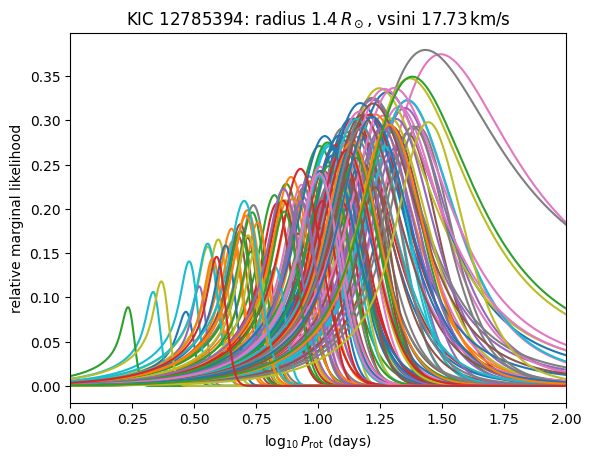

In [16]:
# Itera sobre cada entrada no DataFrame 'd'
for i in range(len(d)):
    _d = d.iloc[i]          # Seleciona a i-ésima linha do DataFrame
    kic = int(_d.kepid)     # Extrai o ID Kepler da estrela, convertendo para inteiro
    print(kic)            

    # Calcula a verossimilhança marginalizada para a estrela atual usando a grade de períodos
    parr, plike = compute_pml(_d, pgrid, upper3)

    # Salva os resultados da verossimilhança em um arquivo de texto
    np.savetxt(outdir + f"{str(kic).zfill(9)}_plike.txt", np.array([parr, plike]).T, fmt='%.8e')

    # Criação de um gráfico para visualizar a verossimilhança marginalizada
    plt.plot(np.log10(parr), plike, '-') 
    plt.xlabel("$\log_{10}P_\mathrm{rot}$ $\mathrm{(days)}$")   
    plt.ylabel("relative marginal likelihood")                  
    plt.xlim(logpmin, logpmax)                                  
    plt.title(f"KIC {_d.kepid}: radius ${_d.rad:.1f}\,R_\odot$, vsini ${_d.vsini:.2f}\,\mathrm{{km/s}}$") 
    plt.savefig(outdir + f"{str(kic).zfill(9)}_plike.png", dpi=200, bbox_inches="tight")
    #plt.close()  # Fecha a figura para liberar memória

In [48]:
# Definição do diretório de onde os dados serão lidos
# que é o mesmo diretório de saída dos dados processados
datadir = outdir
plikes = []     # Lista para armazenar os DataFrames processados

# Itera sobre cada entrada no DataFrame de dados de estrelas 'd'
for i in range(len(d)):
    # Constrói o nome do arquivo para a i-ésima estrela com base no seu ID Kepler
    fname = datadir + str(int(d.iloc[i].kepid)).zfill(9) + "_plike.txt"

    # Leitura dos dados de verossimilhança do arquivo
    _d = pd.read_csv(fname, sep=r"\s+", names=["p", "like"])
    
    # Verificação se há valores NaN na coluna 'like'
    if np.sum(_d.like != _d.like): 
        print(f"{fname} inclui valores ausentes.")
    else:
        # Cálculo da probabilidade de verossimilhança ajustada para cada valor de 'p'
        _d["like_prob"] = _d.like * np.median(np.diff(np.log10(_d.p)))
        
        # Adiciona uma nova coluna para o logaritmo dos períodos
        _d["log10p"] = np.log10(_d.p)
        
        # Filtra os dados dentro dos limites especificados de logaritmo do período
        idx = (logpmin < _d.log10p) & (_d.log10p < logpmax)
        
        # Adiciona os dados filtrados à lista após resetar o índice
        plikes.append(_d[idx].reset_index(drop=True))

print(len(plikes))

144


In [51]:
# Definição do número de bins e de parâmetros do modelo
Nbin = 100                      # Número de bins para dividir os dados
modelname, bsigma = "gpn", 10.  # Nome do modelo e parâmetro sigma do modelo
null = False                    # Indica se o modelo nulo deve ser considerado
noprior = False                 # Indica se um prior deve ser ignorado

# Preparação e cálculo da grade logarítmica dos períodos
logpgrid = jnp.array(jnp.log10(jnp.array(plikes[0].p)))  # Calcula o logaritmo dos períodos

# Definição dos bins do prior de período, ajustando um pequeno incremento para garantir cobertura total
pbins_prior = jnp.linspace(logpmin, logpmax + 1e-4, Nbin + 1)   # Cria uma grade linear de valores de logp
dbin = pbins_prior[1] - pbins_prior[0]                          # Calcula o tamanho de cada bin

# Indexação dos dados na grade de bins
logpidx = jnp.digitize(logpgrid, pbins_prior) - 1               # Aloca cada valor de logp em seu respectivo bin

# Cálculo dos alphas baseados nas distâncias entre os bins
alpha_max = jnp.log(1. / jnp.median(jnp.diff(pbins_prior)))     # Calcula alpha baseado na diferença mediana dos bins
alpha_mean = jnp.log(1. / (logpmax - logpmin))                  # Calcula alpha baseado na extensão total dos logs de período

# Cálculo dos centros dos bins
pbins_center = 0.5 * (pbins_prior[1:] + pbins_prior[:-1])

In [22]:
truth = None
X = device_put(design_matrix(plikes))   # Coloca a matriz de design no dispositivo (GPU ou TPU)
print(np.shape(X))                      # Imprime a forma da matriz de design

# Configuração do kernel NUTS para MCMC
target_accept_prob = 0.9  # Probabilidade aceitável de aceitação para o NUTS
kernel = numpyro.infer.NUTS(model_gp, target_accept_prob=target_accept_prob)  

# Construção do nome base do arquivo para os resultados
basename = outdir + "%s%d" % (modelname, Nbin)  # Formato básico do nome do arquivo
if modelname == "gpn":                          # Se o modelo for gpn, adiciona o sigma do modelo
    basename += "-bs%d" % bsigma
if null:                                        # Se estiver usando o modelo nulo, adiciona o sufixo -null
    basename += "-null"
if noprior:                                     # Se estiver ignorando os priors, adiciona o sufixo -noprior
    basename += "-n"

print(basename)

# Configuração e execução da simulação MCMC
n_sample = 15000  # Número de amostras para a fase de aquecimento e para amostras efetivas
mcmc = numpyro.infer.MCMC(kernel, num_warmup=n_sample, num_samples=n_sample)  # Instancia o objeto MCMC

# Geração de chave aleatória e execução do MCMC
rng_key = random.PRNGKey(0)                       # Chave pseudoaleatória para a geração de números aleatórios
mcmc.run(rng_key, X=X, null=null, noprior=noprior, alpha_mean=alpha_mean, 
        Nbin=Nbin, pbins_center=pbins_center, bsigma=bsigma, dbin=dbin, 
        logpidx=logpidx, logpgrid=logpgrid)  # Executa o MCMC com os dados e configurações

# Impressão do resumo das amostras MCMC
mcmc.print_summary()  # Mostra estatísticas resumidas das cadeias de Markov

# Salvamento do estado do MCMC
with open(basename + "_mcmc.pkl", "wb") as f:   # Abre o arquivo para escrita em modo binário
    dill.dump(mcmc, f)                          # Serializa o objeto MCMC e salva no arquivo

(144, 998)
period_likelihood/gpn100-bs10


sample: 100%|██████████| 30000/30000 [45:15<00:00, 11.05it/s, 1023 steps of size 3.22e-03. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
 alphas[0]     -1.61      1.60     -1.58     -4.24      0.99    371.13      1.00
 alphas[1]     -1.60      1.52     -1.58     -4.19      0.80    330.00      1.00
 alphas[2]     -1.57      1.46     -1.56     -3.98      0.78    293.07      1.00
 alphas[3]     -1.52      1.40     -1.53     -3.74      0.83    265.37      1.00
 alphas[4]     -1.46      1.36     -1.47     -3.66      0.78    243.93      1.00
 alphas[5]     -1.38      1.32     -1.39     -3.53      0.80    224.20      1.00
 alphas[6]     -1.29      1.29     -1.30     -3.38      0.85    208.11      1.00
 alphas[7]     -1.19      1.27     -1.21     -3.32      0.88    196.09      1.00
 alphas[8]     -1.08      1.26     -1.10     -3.16      0.98    186.79      1.00
 alphas[9]     -0.97      1.25     -0.99     -3.00      1.10    180.58      1.00
alphas[10]     -0.85      1.24     -0.88     -2.80      1.31    176.18      1.00
alphas[11]     -0.73      1

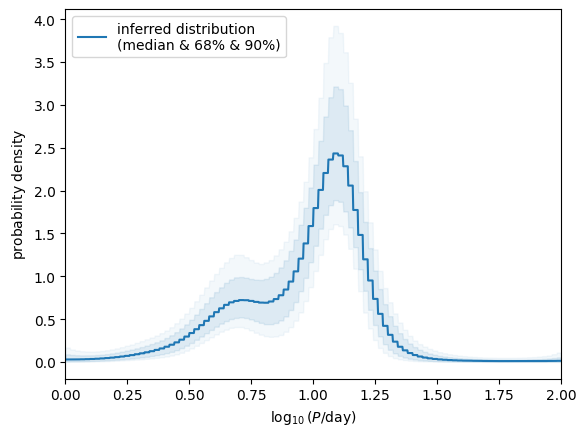

In [24]:
# Extração das amostras MCMC para os parâmetros 'lna', 'lnc' e 'priors'
lna = np.array(mcmc.get_samples()["lna"])
lnc = np.array(mcmc.get_samples()["lnc"])
priors = np.array(mcmc.get_samples()["priors"])

# Cálculo dos percentis 16, 50, e 84 para os priors (equivalentes ao intervalo interquartil)
q = np.percentile(priors, [16, 50, 84], axis=0)

# Cálculo dos percentis 5 e 95 para os priors (intervalo de confiança mais amplo)
q2 = np.percentile(priors, [5, 95], axis=0)

# Cálculo da média e desvio padrão dos priors
qmean = np.mean(priors, axis=0)
qstd = np.std(priors, axis=0)

# Criação do gráfico para visualizar os resultados
plt.figure()
plt.xlabel("$\log_{10}(P/\mathrm{day})$") 
plt.ylabel("$\mathrm{probability\ density}$")
plt.xlim(logpmin, logpmax) 

# Plotagem da distribuição inferida (mediana e intervalos de confiança de 68% e 90%)
plt.plot(logpgrid, q[1], color="C0", label="inferred distribution\n(median & 68% & 90%)")
plt.fill_between(logpgrid, q[0], q[2], color="C0", alpha=0.1)  # Intervalo de confiança de 68%
plt.fill_between(logpgrid, q2[0], q2[1], color="C0", alpha=0.05)  # Intervalo de confiança de 90%

# Adição da legenda e salvamento do gráfico
plt.legend(loc="best")
plt.savefig(basename + "_models.png", dpi=200, bbox_inches="tight")
plt.show()

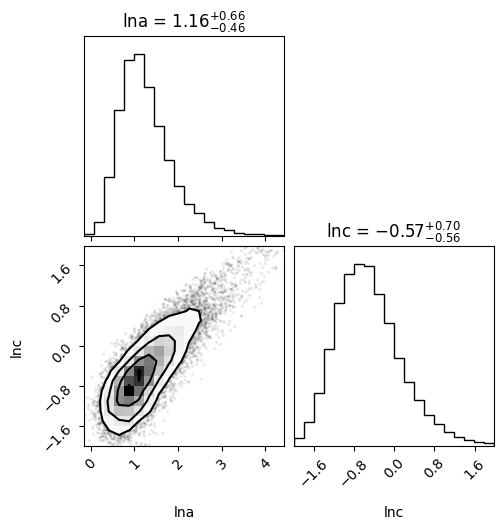

In [25]:
# Preparação das chaves para posterior processamento, removendo algumas específicas
keys = list(mcmc.get_samples().keys())
keys.remove('alphas')
keys.remove('priors')
keys.remove('logpgrid')
keys.remove('norm')

# Verifica se há chaves (parâmetros) para processar
if len(keys):
    # Cria um DataFrame a partir das amostras MCMC para as chaves especificadas
    hyper = pd.DataFrame(data=dict(zip(keys, [mcmc.get_samples()[k] for k in keys])))
    # Remove os sublinhados dos nomes das chaves para melhor apresentação nos gráficos
    labs = [k.replace("_", " ") for k in keys]
    # Utiliza a biblioteca corner para criar gráficos de pares das distribuições dos parâmetros
    fig = corner.corner(hyper, labels=labs, show_titles="%.2f")
    # Salva a figura dos gráficos de pares
    fig.savefig(basename + "_corner.png", dpi=200, bbox_inches="tight")

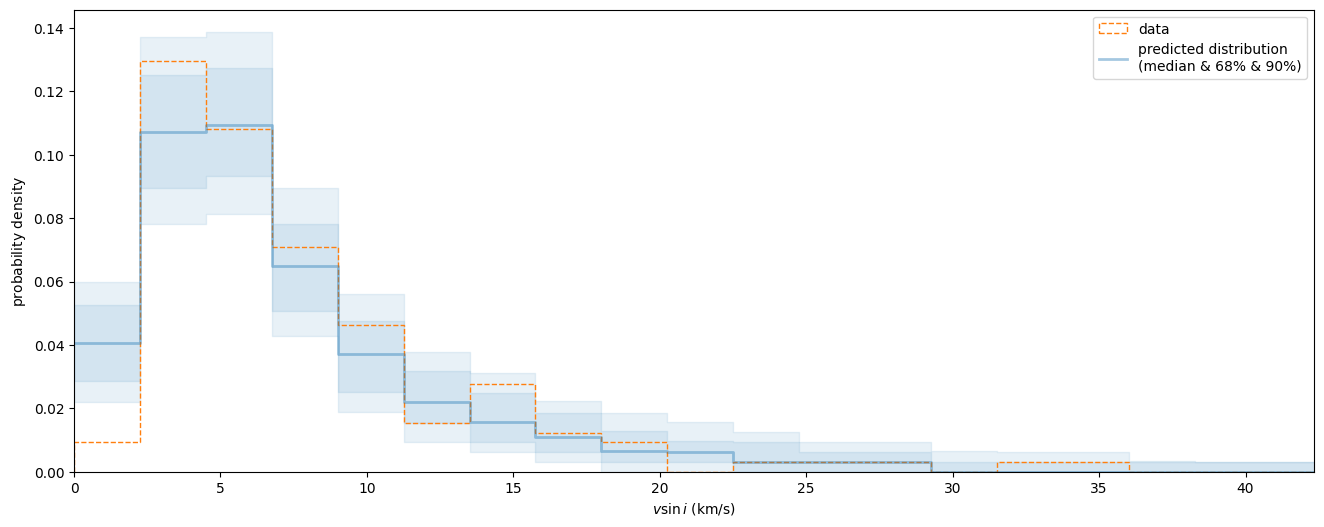

In [26]:
# Amostra vsini e recebe os histogramas e amostras correspondentes
bins, h, bins_cum, hc, _s = sample_vsini(d, mcmc, 1000, log=False)

# Preparação para plotagem dos resultados da distribuição de vsini
sigv = 0  # Definindo um desvio padrão para ajustes na plotagem, se necessário
q = np.percentile(h, [5, 16, 50, 84, 95], axis=0)  # Calcula percentis para as alturas do histograma
plt.figure(figsize=(16, 6))
plt.xlim(bins[0], bins[-1] * 0.99)
plt.xlabel("$v\sin i$ $(\mathrm{km/s})$")
plt.ylabel("$\mathrm{probability\ density}$")
b = np.r_[bins[0], np.repeat(bins[1:-1], 2), bins[-1]]
plt.hist(np.sqrt(d.vsini ** 2 - sigv ** 2), bins=bins, histtype='step', density=True, color='C1', ls='dashed', lw=1, label='data')
plt.plot(b, np.repeat(q[2], 2), '-', color='C0', lw=2, alpha=0.4, label="predicted distribution\n(median & 68% & 90%)")
plt.fill_between(b, np.repeat(q[1], 2), np.repeat(q[3], 2), color="C0", alpha=0.1)
plt.fill_between(b, np.repeat(q[0], 2), np.repeat(q[4], 2), color="C0", alpha=0.1)
plt.legend(loc="best")
plt.savefig(basename + "-vsini.png", dpi=200, bbox_inches="tight")

## Resumo e conclusão 

O paper apresenta uma estrutura probabilística para inferir a distribuição do período de rotação para uma amostra de estrelas com eixos de rotação orientados isotropicamente, com base nos conjuntos de dados que restringem $ v \sin i $ e os raios. Esta inferência baseada em $ v \sin i $ é complementar às medições de período baseadas em modulação de brilho quase periódica nas curvas de luz fotométricas, pois o método fotométrico é sensível apenas a estrelas que exibem grandes variabilidades fotométricas e pode ser tendencioso contra estrelas menos ativas. Nosso método foi testado usando conjuntos de dados simulados (não mostramos aqui mas pode ser visto no paper original) e mostrou funcionar bem para $\approx$ 100 estrelas com as melhores restrições atualmente alcançáveis, a menos que a verdadeira distribuição do período de rotação inclua descontinuidades acentuadas. Para conjuntos de dados com diferentes tamanhos e qualidades, testes semelhantes podem ser obrigatórios para ajustar os priors nos hiperparâmetros a fim de obter resultados sensatos. Também observamos que nossa escolha para o hiperprior é apenas um exemplo que se mostrou funcionar razoavelmente bem para o problema atual. Por exemplo, poderiam ser utilizados frameworks diferentes de processos gausianos (por exemplo, rede neural) para construir o hiperprior $ p(x | \alpha) $. Alternativamente, poderiam ser adotadas distribuições paramétricas mais simples e fisicamente motivadas para $ p(x | \alpha) $, se existirem, o que reduziria muito o número de parâmetros do modelo e simplificaria o processo de amostragem.

Aplicamos nosso método às estrelas Kepler de tipo espectral tardio-F/inicial-G observadas com Keck/HIRES para inferir sua distribuição de períodos de rotação, de forma que não seja tendenciosa contra estrelas com fracas variabilidades fotométricas. Descobrimos que os períodos de rotação típicos dessas estrelas são semelhantes aos valores inferidos a partir da modulação fotométrica, embora tenhamos encontrado evidências de que estrelas jovens e rapidamente rotativas estão super-representadas na amostra fotométrica. Também encontramos uma boa concordância entre nossa inferência e os períodos medidos para estrelas Kepler semelhantes com asterossismologia, incluindo sua dependência das temperaturas efetivas. Essas comparações demonstram a utilidade do método baseado em $ v \sin i $ como um diagnóstico alternativo da rotação estelar, e apoiam a hipótese do enfraquecimento do freio magnético, que a lei de frenagem padrão se quebra pelo menos para algumas estrelas quentes mais velhas do que a metade de suas vidas na sequência principal.

# Aplicação do método de Masuda (2022) nos nossos dados

In [3]:
# Aqui vamos inserir nossas estrelas...
gcs = pd.read_csv("../data/gcs-Fstars.csv")

# ..e os dados de raios que obtemos do GAIA DR2
raios = pd.read_csv("../data/Fstars_with_radius_DR2.csv").rename(
    {"target_id": "Name"}, axis = 1).drop_duplicates(subset="Name")

# Não queremos todas as colunas, vamos pegar somente o necessário
raios_select = raios[["Name", "radius_val", "radius_percentile_lower", "radius_percentile_upper"]]

# Juntando esses dois dataframes com a key Name:
df = pd.merge(gcs, raios_select, on="Name")
print(df.shape, df.dropna(subset={"radius_val"}, axis = 0).shape)

# Ok, podemos dropar nossa amostra
df.dropna(subset={"radius_val"}, axis = 0, inplace=True)

(2869, 80) (2788, 80)


In [42]:
# Criação do diretório se não existir
outdir = "period_likelihood_GCS/"
if not os.path.exists(outdir):
    os.system(f"mkdir {outdir}")

In [45]:
# Essa é a mesma função que o Masuda (2022) define, apenas modifiquei para dar certo nos 
# nossos dados
def compute_pml_gcs(df, parr):
    vsini, sig_vsini = df["vsini"], 1. 
    r, sig_r = df["radius_val"], (df["radius_percentile_upper"] - df["radius_percentile_lower"])/2
    rmin, rmax = df["radius_percentile_lower"], df["radius_percentile_upper"]
    like_vsini = get_like_vsini(vsini, sig_vsini)
    like_r = lambda x: pdf_norm(x, r, sig_r)
    like_p_marg = np.array([p_marg_likelihood(_p, like_vsini, like_r, rmin=rmin, rmax=rmax) for _p in parr])
    return parr, like_p_marg

/tmp/ipykernel_25438/2750021926.py:35: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(integrand_r, rmin, rmax)[0]
/tmp/ipykernel_25438/2750021926.py:35: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(integrand_r, rmin, rmax)[0]


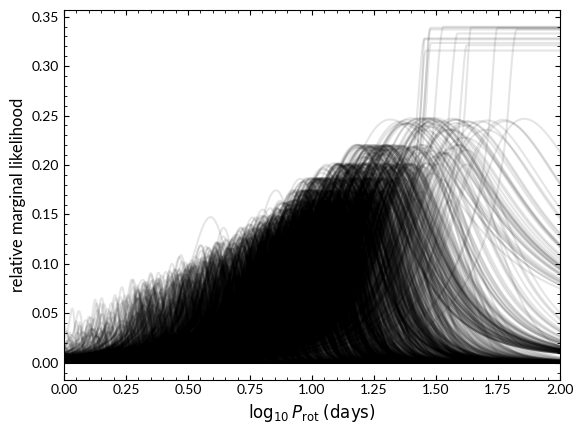

In [43]:
logpmin, logpmax = 0., 2.0  # 0 - 100 DIAS
Ngrid = 1000
pgrid = np.logspace(logpmin, logpmax, Ngrid)

_, ax = plt.subplots()
for i in range(len(df)):
    _d = df.iloc[i]
    hip = int(_d["HIP"])
    parr, plike = compute_pml_gcs(_d, pgrid)
    np.savetxt(outdir + f"{str(hip).zfill(6)}_plike.txt", np.array([parr, plike]).T, fmt='%.8e')

    ax.plot(np.log10(parr), plike, '-', color='black', alpha=0.1)
    ax.set_xlabel("$\log_{10}P_\mathrm{rot}$ $\mathrm{(days)}$")
    ax.set_ylabel("relative marginal likelihood")
    ax.set_xlim(logpmin, logpmax)
    #ax.set_title(f"LAST HIP {_d['HIP']}: radius ${_d['radius_val']:.1f}\,R_\odot$, vsini ${_d['vsini']:.2f}\,\mathrm{{km/s}}$")

In [51]:
datadir = outdir
plikes = [] 

for i in range(len(df)):
    fname = datadir + str(int(df.iloc[i]["HIP"])).zfill(6) + "_plike.txt"
    _d = pd.read_csv(fname, sep=r"\s+", names=["p", "like"])
    
    if np.sum(_d.like != _d.like): 
        print(f"{fname} inclui valores ausentes.")
    else:
        _d["like_prob"] = _d.like * np.median(np.diff(np.log10(_d.p)))
        _d["log10p"] = np.log10(_d.p)
        idx = (logpmin < _d.log10p) & (_d.log10p < logpmax)
        plikes.append(_d[idx].reset_index(drop=True))

print(len(plikes))

2788


In [52]:
Nbin = 100                      
modelname, bsigma = "gpn", 10.   
null = False                    
noprior = False                 

logpgrid = jnp.array(jnp.log10(jnp.array(plikes[0].p))) 
pbins_prior = jnp.linspace(logpmin, logpmax + 1e-4, Nbin + 1)   
dbin = pbins_prior[1] - pbins_prior[0]                         
logpidx = jnp.digitize(logpgrid, pbins_prior) - 1              
alpha_max = jnp.log(1. / jnp.median(jnp.diff(pbins_prior)))    
alpha_mean = jnp.log(1. / (logpmax - logpmin))                 
pbins_center = 0.5 * (pbins_prior[1:] + pbins_prior[:-1])

In [54]:
truth = None
X = device_put(design_matrix(plikes))   
print(np.shape(X))                     

target_accept_prob = 0.9 
kernel = numpyro.infer.NUTS(model_gp, target_accept_prob=target_accept_prob)  

basename = outdir + "%s%d" % (modelname, Nbin)  
if modelname == "gpn":                          
    basename += "-bs%d" % bsigma
if null:                                       
    basename += "-null"
if noprior:                                    
    basename += "-n"

print(basename)

n_sample = 15000 
mcmc = numpyro.infer.MCMC(kernel, num_warmup=n_sample, num_samples=n_sample) 
rng_key = random.PRNGKey(0)                       
mcmc.run(rng_key, X=X, null=null, noprior=noprior, alpha_mean=alpha_mean, 
        Nbin=Nbin, pbins_center=pbins_center, bsigma=bsigma, dbin=dbin, 
        logpidx=logpidx, logpgrid=logpgrid) 
mcmc.print_summary()  

with open(basename + "_mcmc.pkl", "wb") as f: 
    dill.dump(mcmc, f)

(2788, 998)
period_likelihood_GCS/gpn100-bs10


sample: 100%|██████████| 30000/30000 [23:49:42<00:00,  2.86s/it, 255 steps of size 9.03e-03. acc. prob=0.59]    



                mean       std    median      5.0%     95.0%     n_eff     r_hat
 alphas[0]      1.54      0.96      1.52     -0.10      3.13    646.36      1.01
 alphas[1]      1.34      0.94      1.36     -0.26      2.93    634.57      1.01
 alphas[2]      1.15      0.94      1.19     -0.52      2.63    623.09      1.01
 alphas[3]      1.00      0.94      1.02     -0.68      2.46    576.70      1.01
 alphas[4]      0.89      0.95      0.86     -0.78      2.37    541.10      1.01
 alphas[5]      0.83      0.95      0.75     -0.85      2.31    519.08      1.01
 alphas[6]      0.81      0.95      0.72     -0.87      2.30    512.44      1.01
 alphas[7]      0.82      0.95      0.72     -0.90      2.29    517.60      1.01
 alphas[8]      0.87      0.95      0.75     -0.71      2.47    525.34      1.01
 alphas[9]      0.94      0.95      0.79     -0.61      2.54    534.77      1.01
alphas[10]      1.05      0.95      0.89     -0.50      2.66    513.40      1.01
alphas[11]      1.18      0

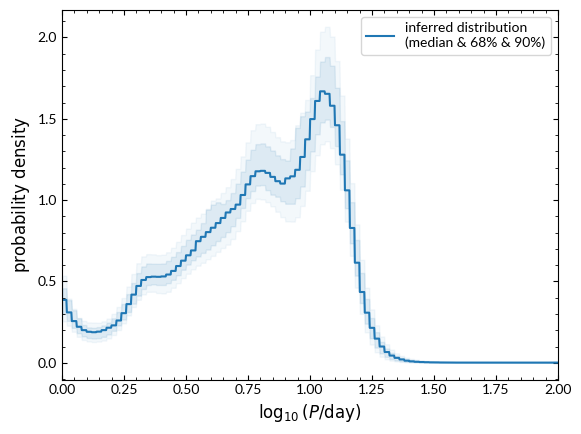

In [55]:
lna = np.array(mcmc.get_samples()["lna"])
lnc = np.array(mcmc.get_samples()["lnc"])
priors = np.array(mcmc.get_samples()["priors"])

q = np.percentile(priors, [16, 50, 84], axis=0)
q2 = np.percentile(priors, [5, 95], axis=0)
qmean = np.mean(priors, axis=0)
qstd = np.std(priors, axis=0)

plt.figure()
plt.xlabel("$\log_{10}(P/\mathrm{day})$") 
plt.ylabel("$\mathrm{probability\ density}$")
plt.xlim(logpmin, logpmax) 

plt.plot(logpgrid, q[1], color="C0", label="inferred distribution\n(median & 68% & 90%)")
plt.fill_between(logpgrid, q[0], q[2], color="C0", alpha=0.1)
plt.fill_between(logpgrid, q2[0], q2[1], color="C0", alpha=0.05) 

if not null:
    if truth is not None:
        plt.plot(logpgrid, truth, '-', color='C1', lw=1, ls='dotted', label='input distribution')
plt.legend(loc="best")
plt.savefig(basename + "_models.png", dpi=200, bbox_inches="tight")
plt.show()

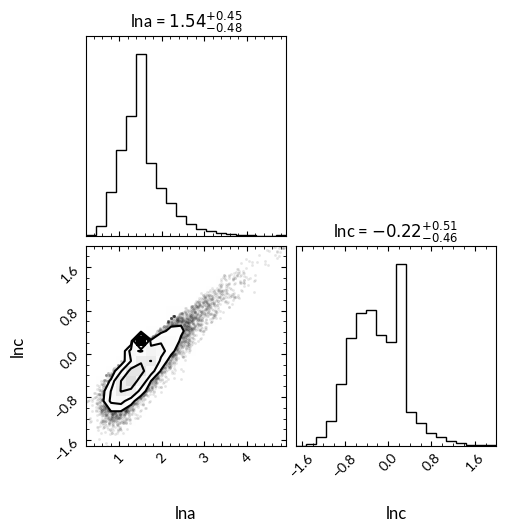

In [56]:
keys = list(mcmc.get_samples().keys())
keys.remove('alphas')
keys.remove('priors')
keys.remove('logpgrid')
keys.remove('norm')

if len(keys):
    hyper = pd.DataFrame(data=dict(zip(keys, [mcmc.get_samples()[k] for k in keys])))
    labs = [k.replace("_", " ") for k in keys]
    fig = corner.corner(hyper, labels=labs, show_titles="%.2f")
    fig.savefig(basename + "_corner.png", dpi=200, bbox_inches="tight")

In [65]:
def sample_vsini_gcs(d, mcmc, N, log=False):
    vmax = np.max(d.vsini) * 1.2
    samples = []

    if log:
        bins = np.logspace(0, np.log10(vmax), 20)
        bins_cum = np.logspace(0, np.log10(vmax), 1000)
    else:
        bins = np.linspace(0, vmax, 20)
        bins_cum = np.linspace(0, vmax, 1000)
    vsinis, vsinis_cum = [], []

    logpgrid = mcmc.get_samples()["logpgrid"][0]

    for i in range(N):
        idx = np.random.choice(len(mcmc.get_samples()["priors"]))
        prior = mcmc.get_samples()["priors"][idx]
        priorcum = np.cumsum(prior) / np.cumsum(prior)[-1]
        rnds = np.random.rand(len(d))
        try:
            logpsample = logpgrid[np.digitize(rnds, priorcum)] - 0.5 * np.diff(logpgrid)[0]
        except:
            pass
        radsample = d["radius_val"] + np.random.randn(len(d)) * (d["radius_percentile_upper"] - d["radius_percentile_lower"])/2
        sinisample = np.sqrt(1 - np.random.rand(len(d)) ** 2)
        vsinisample = vunit * radsample / 10 ** logpsample * sinisample
        vsinisample += np.random.randn(len(d))
        h, _ = np.histogram(vsinisample, bins=bins, density=True)
        vsinis.append(h)
        h, _ = np.histogram(vsinisample, bins=bins_cum, density=True)
        vsinis_cum.append(np.cumsum(h) / np.cumsum(h)[-1])
        samples.append(list(vsinisample))
    return bins, np.array(vsinis), bins_cum, np.array(vsinis_cum), np.array(samples)

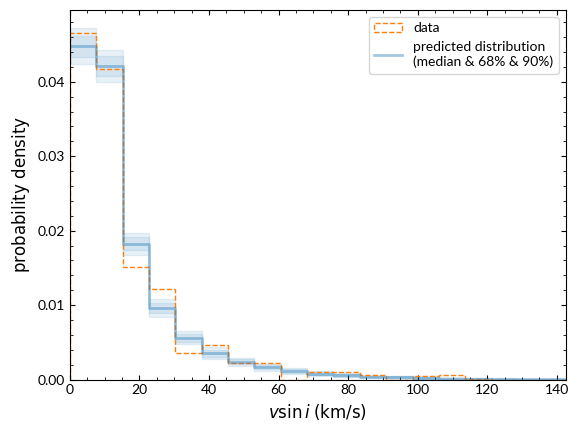

In [59]:
bins, h, bins_cum, hc, _s = sample_vsini_gcs(df, mcmc, 1000, log=False)

sigv = 0 
q = np.percentile(h, [5, 16, 50, 84, 95], axis=0) 
plt.figure()
plt.xlim(bins[0], bins[-1] * 0.99)
plt.xlabel("$v\sin i$ $(\mathrm{km/s})$")
plt.ylabel("$\mathrm{probability\ density}$")
b = np.r_[bins[0], np.repeat(bins[1:-1], 2), bins[-1]]
plt.hist(np.sqrt(df["vsini"] ** 2 - sigv ** 2), bins=bins, histtype='step', density=True, color='C1', ls='dashed', lw=1, label='data')
plt.plot(b, np.repeat(q[2], 2), '-', color='C0', lw=2, alpha=0.4, label="predicted distribution\n(median & 68% & 90%)")
plt.fill_between(b, np.repeat(q[1], 2), np.repeat(q[3], 2), color="C0", alpha=0.1)
plt.fill_between(b, np.repeat(q[0], 2), np.repeat(q[4], 2), color="C0", alpha=0.1)
plt.legend(loc="best")
plt.savefig(basename + "-vsini.png", dpi=200, bbox_inches="tight")

## Análises para o artigo

In [68]:
# Aqui vamos inserir nossas estrelas...
gcs = pd.read_csv("../data/gcs-Fstars.csv")

# ..e os dados de raios que obtemos do GAIA DR2
raios = pd.read_csv("../data/Fstars_with_radius_DR2.csv").rename(
    {"target_id": "Name"}, axis = 1).drop_duplicates(subset="Name")

# Não queremos todas as colunas, vamos pegar somente o necessário
raios_select = raios[["Name", "radius_val", "radius_percentile_lower", "radius_percentile_upper"]]

# Juntando esses dois dataframes com a key Name:
df = pd.merge(gcs, raios_select, on="Name")
print(df.shape, df.dropna(subset={"radius_val"}, axis = 0).shape)

# Ok, podemos dropar nossa amostra
df.dropna(subset={"radius_val"}, axis = 0, inplace=True)

(2869, 80) (2788, 80)


In [69]:
# Carregando o nosso modelo (que fizemos em cima)
outdir = "period_likelihood_GCS/"
with open(outdir + "gpn100-bs10_mcmc.pkl", "rb") as f:
    mcmc_loaded = dill.load(f)

# Criando uma pasta para salvar as figuras (que possivelmente pode ir para o artigo)
if not os.path.exists("figures"):
    os.system(f"mkdir {outdir}")

In [70]:
# Aqui eu só estou recuperando os dados que fizemos anteriormente
datadir = outdir
logpmin, logpmax = 0., 2.0  # 0 - 100 DIAS
plikes = [] 

for i in range(len(df)):
    fname = datadir + str(int(df.iloc[i]["HIP"])).zfill(6) + "_plike.txt"
    _d = pd.read_csv(fname, sep=r"\s+", names=["p", "like"])
    
    if np.sum(_d.like != _d.like): 
        print(f"{fname} inclui valores ausentes.")
    else:
        _d["like_prob"] = _d.like * np.median(np.diff(np.log10(_d.p)))
        _d["log10p"] = np.log10(_d.p)
        idx = (logpmin < _d.log10p) & (_d.log10p < logpmax)
        plikes.append(_d[idx].reset_index(drop=True))

In [103]:
bins, h, bins_cum, hc, _s = sample_vsini_gcs(df, mcmc_loaded, len(df), log=True)
b = np.r_[bins_cum[0], np.repeat(bins_cum[1:-1], 2), bins_cum[-1]]

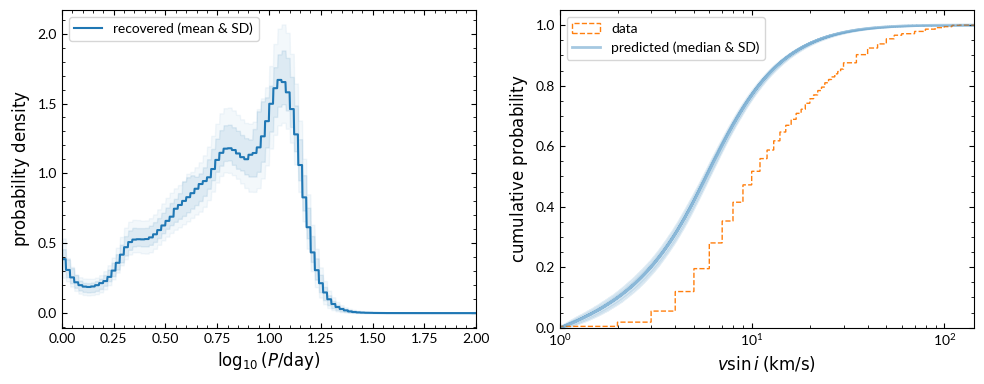

In [110]:
logpgrid = jnp.array(jnp.log10(jnp.array(plikes[0]["p"]))) 
lna = np.array(mcmc_loaded.get_samples()["lna"])
lnc = np.array(mcmc_loaded.get_samples()["lnc"])
priors = np.array(mcmc_loaded.get_samples()["priors"])

q = np.percentile(priors, [16, 50, 84], axis=0)
q2 = np.percentile(priors, [5, 95], axis=0)
qmean = np.mean(priors, axis=0)
qstd = np.std(priors, axis=0)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Primeiro gráfico
ax1.plot(logpgrid, q[1], color="C0", label="recovered (mean & SD)")
ax1.fill_between(logpgrid, q[0], q[2], color="C0", alpha=0.1)
ax1.fill_between(logpgrid, q2[0], q2[1], color="C0", alpha=0.05)

ax1.set_xlabel("$\log_{10}(P/\mathrm{day})$")
ax1.set_ylabel("$\mathrm{probability\ density}$")
ax1.set_xlim(logpmin, logpmax)
ax1.legend()

# Segundo gráfico
sigv = 0
q = np.percentile(hc, [5, 16, 50, 84, 95], axis=0)

ax2.hist(np.sqrt(df.vsini**2-sigv**2), bins=bins_cum, histtype='step', cumulative=True, density=True, color='C1', ls='dashed', lw=1, label="data")
ax2.plot(b, np.repeat(q[2], 2), '-', color='C0', lw=2, alpha=0.4, label=u"predicted (median & SD)")
plt.fill_between(b, np.repeat(q[1], 2), np.repeat(q[3], 2), color="C0", alpha=0.1)
plt.fill_between(b, np.repeat(q[0], 2), np.repeat(q[4], 2), color="C0", alpha=0.1)

ax2.set_xscale("log")
ax2.set_xlim(bins_cum[0], bins_cum[-1]*0.99)
ax2.set_xlabel("$v\sin i$ $(\mathrm{km/s})$")
ax2.set_ylabel("$\mathrm{cumulative\ probability}$")
ax2.legend(loc="best")

plt.tight_layout()
plt.show()

In [144]:
results = []

for i in range(len(df)):
    fname = datadir + str(int(df.iloc[i]["HIP"])).zfill(6) + "_plike.txt"
    _d = pd.read_csv(fname, sep=r"\s+", names=["p", "like"])
    max_like_idx = _d['like'].idxmax()
    max_p_value = _d.loc[max_like_idx, 'p']
    results.append({
        "HIP": df.iloc[i]["HIP"],
        "p_max_like": max_p_value
    })

results_df = pd.DataFrame(results)

In [147]:
# Juntando esses dois dataframes com a key HIP:
df_final = pd.merge(df, results_df, on="HIP")

In [149]:
df_final.to_csv("../data/Fstars_with_periods_masuda.csv", index=False)